In [30]:
import gdsfactory as gf
import numpy as np
import math

gf.gpdk.PDK.activate()

In [31]:
def R_engine(wavelength,neff,ng,FSR):

    R = 1000 * (wavelength)**2 / (2*math.pi*FSR*ng)

    m = neff*2*math.pi*R/wavelength

    new_R = round(m) * wavelength/(neff*2*math.pi)

    new_FSR = 1000 * (wavelength)**2 / (2*math.pi*new_R*ng)

    return new_R, new_FSR


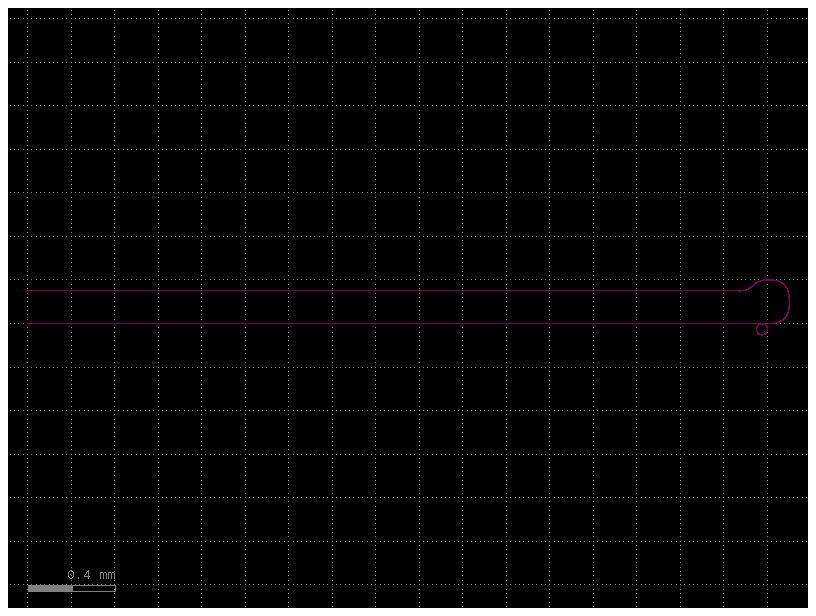

In [32]:
def Ring_based_sensor(R_sensor_radius =197/2,
                      ng_R_sens = 4.9,

                      R1_radius =197/2,
                      ng_R1 = 4.9,

                      R2_radius =197/2,
                      ng_R2 = 4.9,

                      R3_radius =197/2,
                      ng_R3 = 4.9,

                      R4_radius =197/2,
                      ng_R4 = 4.9,

                      R5_radius =197/2,
                      ng_R5 = 4.9,

                      R6_radius =197/2,
                      ng_R6 = 4.9,

                        # Generic parameters
                      wavelength = 1.310,
                      wg_width = 1.5,
                      wg_miltimode_width = 3,
                      wg_multimode_length = 200,
                      separation = 80,
                      neff= 1.574385, # for 1.2 um width, 220nm thick at 1310nm SiN
                      FSR = 2.2,
                      taper_length = 200,
                      Ring_based_pos = (0,0),
                      gap_sensor = 0.150,
                      gap_spec = 0.150,
                      bend_radius = 100,
                      entry_strip_length= 1000,
                      layer = (733,727),):


    ## Cálculo del delta de L

    new_R_sens,new_FSR_sens = R_engine(wavelength,neff,ng_R_sens,FSR)
    new_R1,new_FSR_R1 = R_engine(wavelength,neff,ng_R1,FSR)
    new_R2,new_FSR_R2 = R_engine(wavelength,neff,ng_R2,FSR)
    new_R3,new_FSR_R3 = R_engine(wavelength,neff,ng_R3,FSR)
    new_R4,new_FSR_R4 = R_engine(wavelength,neff,ng_R4,FSR)
    new_R5,new_FSR_R5 = R_engine(wavelength,neff,ng_R5,FSR)
    new_R6,new_FSR_R6 = R_engine(wavelength,neff,ng_R6,FSR)


    # //////  INICIO DE LA FUNCIÓN
    # We define an sketch where we will place the components
    c = gf.Component()

    ######################################################################## INPUT LIGHT #####################################################################################

    ############## Multimode_in ###################

    cross_Multimode_light_in = gf.cross_section.strip(
    width=wg_miltimode_width,
    layer=layer
    )

    mltmode_strip_light_in = gf.components.straight(length=wg_multimode_length,cross_section=cross_Multimode_light_in)
    mltmode_strip_light_in_REF = c.add_ref(mltmode_strip_light_in)
    mltmode_strip_light_in_REF.move((Ring_based_pos[0],Ring_based_pos[1]))

    ###############################################

    ############## Taper In ######################

    cross_taper_in_light_in = gf.cross_section.strip(
    width=wg_miltimode_width,
    layer=layer
    )
    cross_taper_out_light_in = gf.cross_section.strip(
    width=wg_width,
    layer=layer
    )

    taper_light_in = gf.components.taper_cross_section(length=taper_length,cross_section1=cross_taper_in_light_in,cross_section2=cross_taper_out_light_in)
    taper_light_in_ref = c.add_ref(taper_light_in)
    taper_light_in_ref.connect("o1", mltmode_strip_light_in_REF.ports["o2"])

    ##############################################

    ############## Strip SM light in ###################

    cross_sm_strip_light_in = gf.cross_section.strip(
    width=wg_width,
    layer=layer
    )

    strip_light_in = gf.components.straight(length=entry_strip_length,cross_section=cross_sm_strip_light_in)
    strip_light_in_REF = c.add_ref(strip_light_in)
    strip_light_in_REF.connect("o1", taper_light_in_ref.ports["o2"])

    ###############################################

    ############## Bend through 1 ###################

    Bend_through_1 = gf.components.bend_euler(width=wg_width,radius=bend_radius, angle= 90,layer = layer)
    Bend_through_1_REF = c.add_ref(Bend_through_1)
    Bend_through_1_REF.connect("o1", strip_light_in_REF.ports["o2"])

    ###########################################

    ############## Bend through 2 ###################

    Bend_through_2 = gf.components.bend_euler(width=wg_width,radius=bend_radius, angle= 90,layer = layer)
    Bend_through_2_REF = c.add_ref(Bend_through_2)
    Bend_through_2_REF.connect("o1", Bend_through_1_REF.ports["o2"])

    ###########################################


    # Calculo del ángulo entre bends con respecto a la separación entre waveguides:

    A = (2*bend_radius-separation)/(separation)

    C = (math.sqrt(A**2+4*(A+1))-A)/(2*(A+1))

    theta_rad = math.acos(    C    )

    theta_deg = math.acos(    C    )*(180/math.pi)

    y_2 = (2*bend_radius*math.tan(theta_rad))/(1+math.tan(theta_rad/2)*math.tan(theta_rad))

    out_strip_length = entry_strip_length - y_2

    ############## Bend through 3 and 4, then strip ###################

    cross_sm_strip_light_out = gf.cross_section.strip(
    width=wg_width,
    layer=layer
    )

    if theta_deg != 0:
        Bend_through_3 = gf.components.bend_euler(width=wg_width,radius=bend_radius, angle= theta_deg,layer = layer)
        Bend_through_3_REF = c.add_ref(Bend_through_3)
        Bend_through_3_REF.connect("o1", Bend_through_2_REF.ports["o2"])

        Bend_through_4 = gf.components.bend_euler(width=wg_width,radius=bend_radius, angle= -theta_deg,layer = layer)
        Bend_through_4_REF = c.add_ref(Bend_through_4)
        Bend_through_4_REF.connect("o1", Bend_through_3_REF.ports["o2"])

        strip_light_out = gf.components.straight(length=out_strip_length,cross_section=cross_sm_strip_light_out)
        strip_light_out_REF = c.add_ref(strip_light_out)
        strip_light_out_REF.connect("o1", Bend_through_4_REF.ports["o2"])

    else:
        strip_light_out = gf.components.straight(length=out_strip_length,cross_section=cross_sm_strip_light_out)
        strip_light_out_REF = c.add_ref(strip_light_out)
        strip_light_out_REF.connect("o1", Bend_through_2_REF.ports["o2"])


    #################################################

    ############## Taper out ######################

    cross_taper_in_light_out = gf.cross_section.strip(
    width=wg_width,
    layer=layer
    )
    cross_taper_out_light_out = gf.cross_section.strip(
    width=wg_miltimode_width,
    layer=layer
    )

    taper_light_out = gf.components.taper_cross_section(length=taper_length,cross_section1=cross_taper_in_light_out,cross_section2=cross_taper_out_light_out)
    taper_light_out_ref = c.add_ref(taper_light_out)
    taper_light_out_ref.connect("o1", strip_light_out_REF.ports["o2"])

    ##############################################

    ############## Multimode_out ###################

    cross_Multimode_light_out = gf.cross_section.strip(
    width=wg_miltimode_width,
    layer=layer
    )

    mltmode_strip_light_out = gf.components.straight(length=wg_multimode_length,cross_section=cross_Multimode_light_out)
    mltmode_strip_light_out_REF = c.add_ref(mltmode_strip_light_out)
    mltmode_strip_light_out_REF.connect("o1", taper_light_out_ref.ports["o2"])

    ###############################################


    ######################################################################## INPUT LIGHT #################################################################################

    ######################################################################## ADD DROP SENSOR RING ########################################################################

    ##############    Sensing Ring   #######################

    x_ring_sens = strip_light_in_REF.ports["o2"].center[0]
    y_ring_sens = strip_light_in_REF.ports["o2"].center[1]


    Sens_ring = gf.components.rings.ring(radius=new_R_sens, width=wg_width, angle_resolution=2.5, layer=layer, angle=360).copy()
    Sens_ring_REF = c.add_ref(Sens_ring)
    Sens_ring_REF.move((x_ring_sens - new_R_sens ,y_ring_sens - (new_R_sens + wg_width + gap_sensor) ))

    #################################################



    ############## Strip SM DROP from sens ring ###################

    cross_sm_strip_light_in = gf.cross_section.strip(
    width=wg_width,
    layer=layer
    )

    strip_light_in = gf.components.straight(length=entry_strip_length,cross_section=cross_sm_strip_light_in)
    strip_light_in_REF = c.add_ref(strip_light_in)
    strip_light_in_REF.connect("o1", taper_light_in_ref.ports["o2"])

    ###############################################



    ######################################################################## ADD DROP SENSOR RING ########################################################################



    return c

Ring_based_sensor_scketch = gf.Component()

y_pos = 0

Ring_based_sensor = Ring_based_sensor(separation=150, entry_strip_length=3000)
Ring_based_sensor_scketch.add_ref(Ring_based_sensor)

Ring_based_sensor_scketch.draw_ports()
Ring_based_sensor_scketch.plot()
# Ring_based_sensor_scketch.write("RR_SiN_Juanes_1.gds")
Ring_based_sensor_scketch.show()